# Análisis Exploratorio de Datos — Calidad del Aire

## Contexto
Este notebook realiza el análisis exploratorio inicial (EDA) sobre los datos recolectados por sensores de calidad del aire. El conjunto de datos contiene mediciones de múltiples contaminantes y variables meteorológicas registradas por distintos sensores en diferentes periodos de tiempo.

**Estructura del análisis:**
1. Carga y exploración inicial de los datos
2. Identificación de variables y su relevancia
3. Filtrado por ubicación específica (Sensor D)
4. Estadísticas descriptivas
5. Análisis de valores nulos y outliers
6. Distribuciones
7. Series temporales
8. Correlaciones
9. Análisis por hora del día

## 0. Importación de librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde, skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# Estilo general de gráficas
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10
})

---
## 1. Carga de datos

In [4]:
# Nomenclatura / diccionario de variables
nom = pd.read_excel('Data/Nomenclatura_Maestro.xlsx')
print('=== Nomenclatura del dataset ===')
display(nom)

=== Nomenclatura del dataset ===


,Sensor,Periodo,PPM,PPB,TVOC,AQI,ugm3,pct
0,"A , B, C, D, E","P1, P2, P3",Partes por millon,Partes por mil millones,Compuestos Orgánicos Volátiles Totales,Índice de Calidad del Aire,Micro gramos por metro cúbico,Porcentaje
1,Sensor_Periodo,NaN,Unidad,Unidad,Medida con ppb,No tiene unidades,NaN,NaN
2,Nombre del sensor y en que periodo de lectura ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Dataset principal
df = pd.read_excel('Data/Datos_maestro_sensores.xlsx')
df['datetime'] = pd.to_datetime(df['datetime'])

print(f'Dimensiones: {df.shape[0]:,} registros × {df.shape[1]} columnas')
print(f'Periodo total: {df["datetime"].min()} → {df["datetime"].max()}')
df.head()

Dimensiones: 28,654 registros × 14 columnas
Periodo total: 2025-11-06 20:09:35 → 2025-11-25 13:24:23


,sensor_periodo,datetime,CO2_ppm,TVOC_ppb,AQI,CO_ppm,SO2_ppm,O3_ppm,NO2_ppm,PM2_5_ugm3,PM10_ugm3,temp_C,hum_pct,Bat_pct
0,D_P1,2025-11-06 20:09:35,1471.21,3722.70,5,1.225555,0.020990,0.008659,0.010098,22,26,21.9,33.3,57.8
1,D_P1,2025-11-06 20:10:18,1355.02,2765.60,5,1.126044,0.022898,0.011206,0.013286,21,24,21.8,33.4,57.5
2,D_P1,2025-11-06 20:11:19,1219.80,2015.61,4,1.073670,0.022898,0.010188,0.011161,21,25,21.7,33.2,57.6
3,D_P1,2025-11-06 20:12:19,1131.86,1576.97,4,1.087637,0.022135,0.010697,0.011692,20,23,21.7,33.6,57.7
4,D_P1,2025-11-06 20:13:20,1072.33,1301.72,4,1.042246,0.022517,0.009678,0.011692,20,22,21.4,33.5,57.8


In [6]:
print('Sensores y periodos disponibles:')
print(df['sensor_periodo'].value_counts().to_string())

Sensores y periodos disponibles:
sensor_periodo
E_P2    8343
D_P2    7550
C_P2    6553
D_P1    6208


---
## 2. Identificación de variables y su relevancia

El dataset contiene **14 columnas**. A continuación se describe cada variable, su unidad y su relevancia para el estudio de calidad del aire:

| Variable | Unidad | Descripción | Relevancia |
|---|---|---|---|
| `sensor_periodo` | — | Identificador del sensor y periodo de lectura | Llave de agrupación |
| `datetime` | — | Marca temporal de la lectura | Eje temporal del análisis |
| `CO2_ppm` | ppm | Dióxido de carbono | Indicador de ventilación y actividad humana |
| `TVOC_ppb` | ppb | Compuestos Orgánicos Volátiles Totales | Indicador de contaminación por solventes, pinturas y procesos industriales |
| `AQI` | adimensional | Índice de Calidad del Aire | **Variable objetivo potencial**: resume la calidad del aire en una escala de 1–5 |
| `CO_ppm` | ppm | Monóxido de carbono | Gas tóxico; alta correlación con tráfico vehicular y combustión incompleta |
| `SO2_ppm` | ppm | Dióxido de azufre | Indicador de actividad industrial y emisiones de azufre |
| `O3_ppm` | ppm | Ozono troposférico | Contaminante secundario; se forma con luz solar + NOx + COV |
| `NO2_ppm` | ppm | Dióxido de nitrógeno | Asociado a tráfico y combustión; precursor de ozono |
| `PM2_5_ugm3` | µg/m³ | Partículas finas (≤ 2.5 µm) | Alta incidencia en salud respiratoria y cardiovascular |
| `PM10_ugm3` | µg/m³ | Partículas gruesas (≤ 10 µm) | Polvo, pólenes; impacto en vías respiratorias superiores |
| `temp_C` | °C | Temperatura | Variable meteorológica; afecta la dispersión de contaminantes |
| `hum_pct` | % | Humedad relativa | Variable meteorológica; influye en la formación de partículas secundarias |
| `Bat_pct` | % | Nivel de batería del sensor | Variable operacional; no relevante para el modelo de calidad del aire |

> **Nota:** `Bat_pct` se excluirá de los análisis de calidad del aire por ser una variable operacional del dispositivo, no ambiental.

---
## 3. Filtrado por ubicación: Sensor D

Se selecciona el **Sensor D** porque es el único con dos periodos de medición (`D_P1` y `D_P2`), lo que permite:
- Analizar la consistencia del sensor a lo largo del tiempo.
- Comparar comportamientos en distintas semanas.
- Contar con el mayor volumen de datos de una misma ubicación (13,758 registros).

| Periodo | Inicio | Fin | Registros |
|---|---|---|---|
| D_P1 | 2025-11-06 | 2025-11-11 | 6,208 |
| D_P2 | 2025-11-13 | 2025-11-25 | 7,550 |

In [7]:
# Filtrar Sensor D y ordenar por tiempo
sensor_d = df[df['sensor_periodo'].str.startswith('D')].copy()
sensor_d = sensor_d.sort_values('datetime').reset_index(drop=True)

# Columnas de análisis (excluimos Bat_pct y sensor_periodo)
vars_ambientales = ['CO2_ppm','TVOC_ppb','AQI','CO_ppm','SO2_ppm',
                    'O3_ppm','NO2_ppm','PM2_5_ugm3','PM10_ugm3','temp_C','hum_pct']

print(f'Total registros Sensor D: {len(sensor_d):,}')
print()
for sp in ['D_P1','D_P2']:
    sub = sensor_d[sensor_d['sensor_periodo'] == sp]
    print(f'{sp}: {sub["datetime"].min().date()} → {sub["datetime"].max().date()} ({len(sub):,} registros)')

Total registros Sensor D: 13,758

D_P1: 2025-11-06 → 2025-11-11 (6,208 registros)
D_P2: 2025-11-13 → 2025-11-25 (7,550 registros)


---
## 4. Estadísticas descriptivas

In [8]:
desc = sensor_d[vars_ambientales].describe().T
desc['skewness'] = sensor_d[vars_ambientales].apply(skew)
desc['kurtosis'] = sensor_d[vars_ambientales].apply(kurtosis)
desc = desc.round(3)
print('=== Estadísticas descriptivas — Sensor D ===')
display(desc)

=== Estadísticas descriptivas — Sensor D ===


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
CO2_ppm,13758.0,743.111,724.127,400.000,539.672,664.475,814.728,25979.920,15.998,358.612
TVOC_ppb,13758.0,470.997,1719.839,0.000,94.768,178.005,341.890,44927.890,11.699,179.661
AQI,13758.0,2.349,0.931,1.000,2.000,2.000,3.000,5.000,0.508,0.048
CO_ppm,13758.0,0.723,1.125,0.201,0.309,0.419,0.657,8.729,5.461,33.152
SO2_ppm,13758.0,0.010,0.014,0.001,0.003,0.006,0.012,0.353,6.073,76.452
O3_ppm,13758.0,0.012,0.011,0.001,0.009,0.012,0.015,0.500,25.951,1017.512
NO2_ppm,13758.0,0.017,0.011,0.001,0.010,0.016,0.022,0.357,4.225,96.715
PM2_5_ugm3,13758.0,14.905,15.766,1.000,6.000,12.000,20.000,544.000,11.113,294.407
PM10_ugm3,13758.0,16.290,14.419,1.000,6.000,13.000,22.000,192.000,2.698,15.268
temp_C,13758.0,23.252,8.415,1.400,18.300,21.300,25.800,61.600,2.087,5.591


**Observaciones clave:**
- `CO2_ppm` tiene una media de ~743 ppm, pero un máximo de casi 26,000 ppm, lo que sugiere episodios de contaminación extrema o posibles errores del sensor.
- `TVOC_ppb` y `CO_ppm` presentan alta asimetría positiva (skewness elevado), indicando distribuciones con colas largas hacia valores altos.
- `AQI` oscila entre 1 y 5 (su rango natural), con media ~2.35, sugiriendo que la calidad del aire en esta ubicación se mantiene generalmente en niveles bajos a moderados.
- `temp_C` tiene un mínimo de 1.4°C y un máximo de 61.6°C, valores que podrían indicar outliers del sensor.

---
## 5. Análisis de valores nulos y outliers

In [9]:
# Valores nulos
nulos = sensor_d[vars_ambientales].isnull().sum()
print('Valores nulos por variable:')
print(nulos)
print()
print('El dataset no contiene valores faltantes en las variables ambientales.')

Valores nulos por variable:
CO2_ppm       0
TVOC_ppb      0
AQI           0
CO_ppm        0
SO2_ppm       0
O3_ppm        0
NO2_ppm       0
PM2_5_ugm3    0
PM10_ugm3     0
temp_C        0
hum_pct       0
dtype: int64

El dataset no contiene valores faltantes en las variables ambientales.


In [10]:
# Outliers usando regla de 3 desviaciones estándar
print(f"{'Variable':<18} {'Outliers':>8} {'% del total':>12} {'Umbral superior':>18}")
print('-' * 60)
for col in vars_ambientales:
    m = sensor_d[col].mean()
    s = sensor_d[col].std()
    n_out = ((sensor_d[col] > m + 3*s) | (sensor_d[col] < m - 3*s)).sum()
    pct = 100 * n_out / len(sensor_d)
    umbral = m + 3*s
    print(f"{col:<18} {n_out:>8,} {pct:>11.1f}% {umbral:>18.3f}")

Variable           Outliers  % del total    Umbral superior
------------------------------------------------------------
CO2_ppm                 128         0.9%           2915.493
TVOC_ppb                194         1.4%           5630.514
AQI                       0         0.0%              5.142
CO_ppm                  293         2.1%              4.098
SO2_ppm                 308         2.2%              0.053
O3_ppm                   14         0.1%              0.046
NO2_ppm                  17         0.1%              0.051
PM2_5_ugm3               99         0.7%             62.203
PM10_ugm3               192         1.4%             59.546
temp_C                  454         3.3%             48.497
hum_pct                   3         0.0%             87.129


**Interpretación de outliers:**
- `temp_C` presenta el mayor porcentaje de outliers (3.3%), probablemente relacionado con lecturas erróneas del sensor o condiciones extremas.
- `SO2_ppm` y `CO_ppm` también muestran valores atípicos que podrían corresponder a eventos de contaminación puntuales (vehículos, quemas, etc.).
- Las variables de partículas (`PM2_5`, `PM10`) tienen outliers moderados (~0.7–1.4%), consistentes con episodios de polvo o tráfico intenso.

> Para el modelado se evaluará si conviene eliminar, winsorizar o mantener estos valores.

---
## 6. Distribuciones de las variables

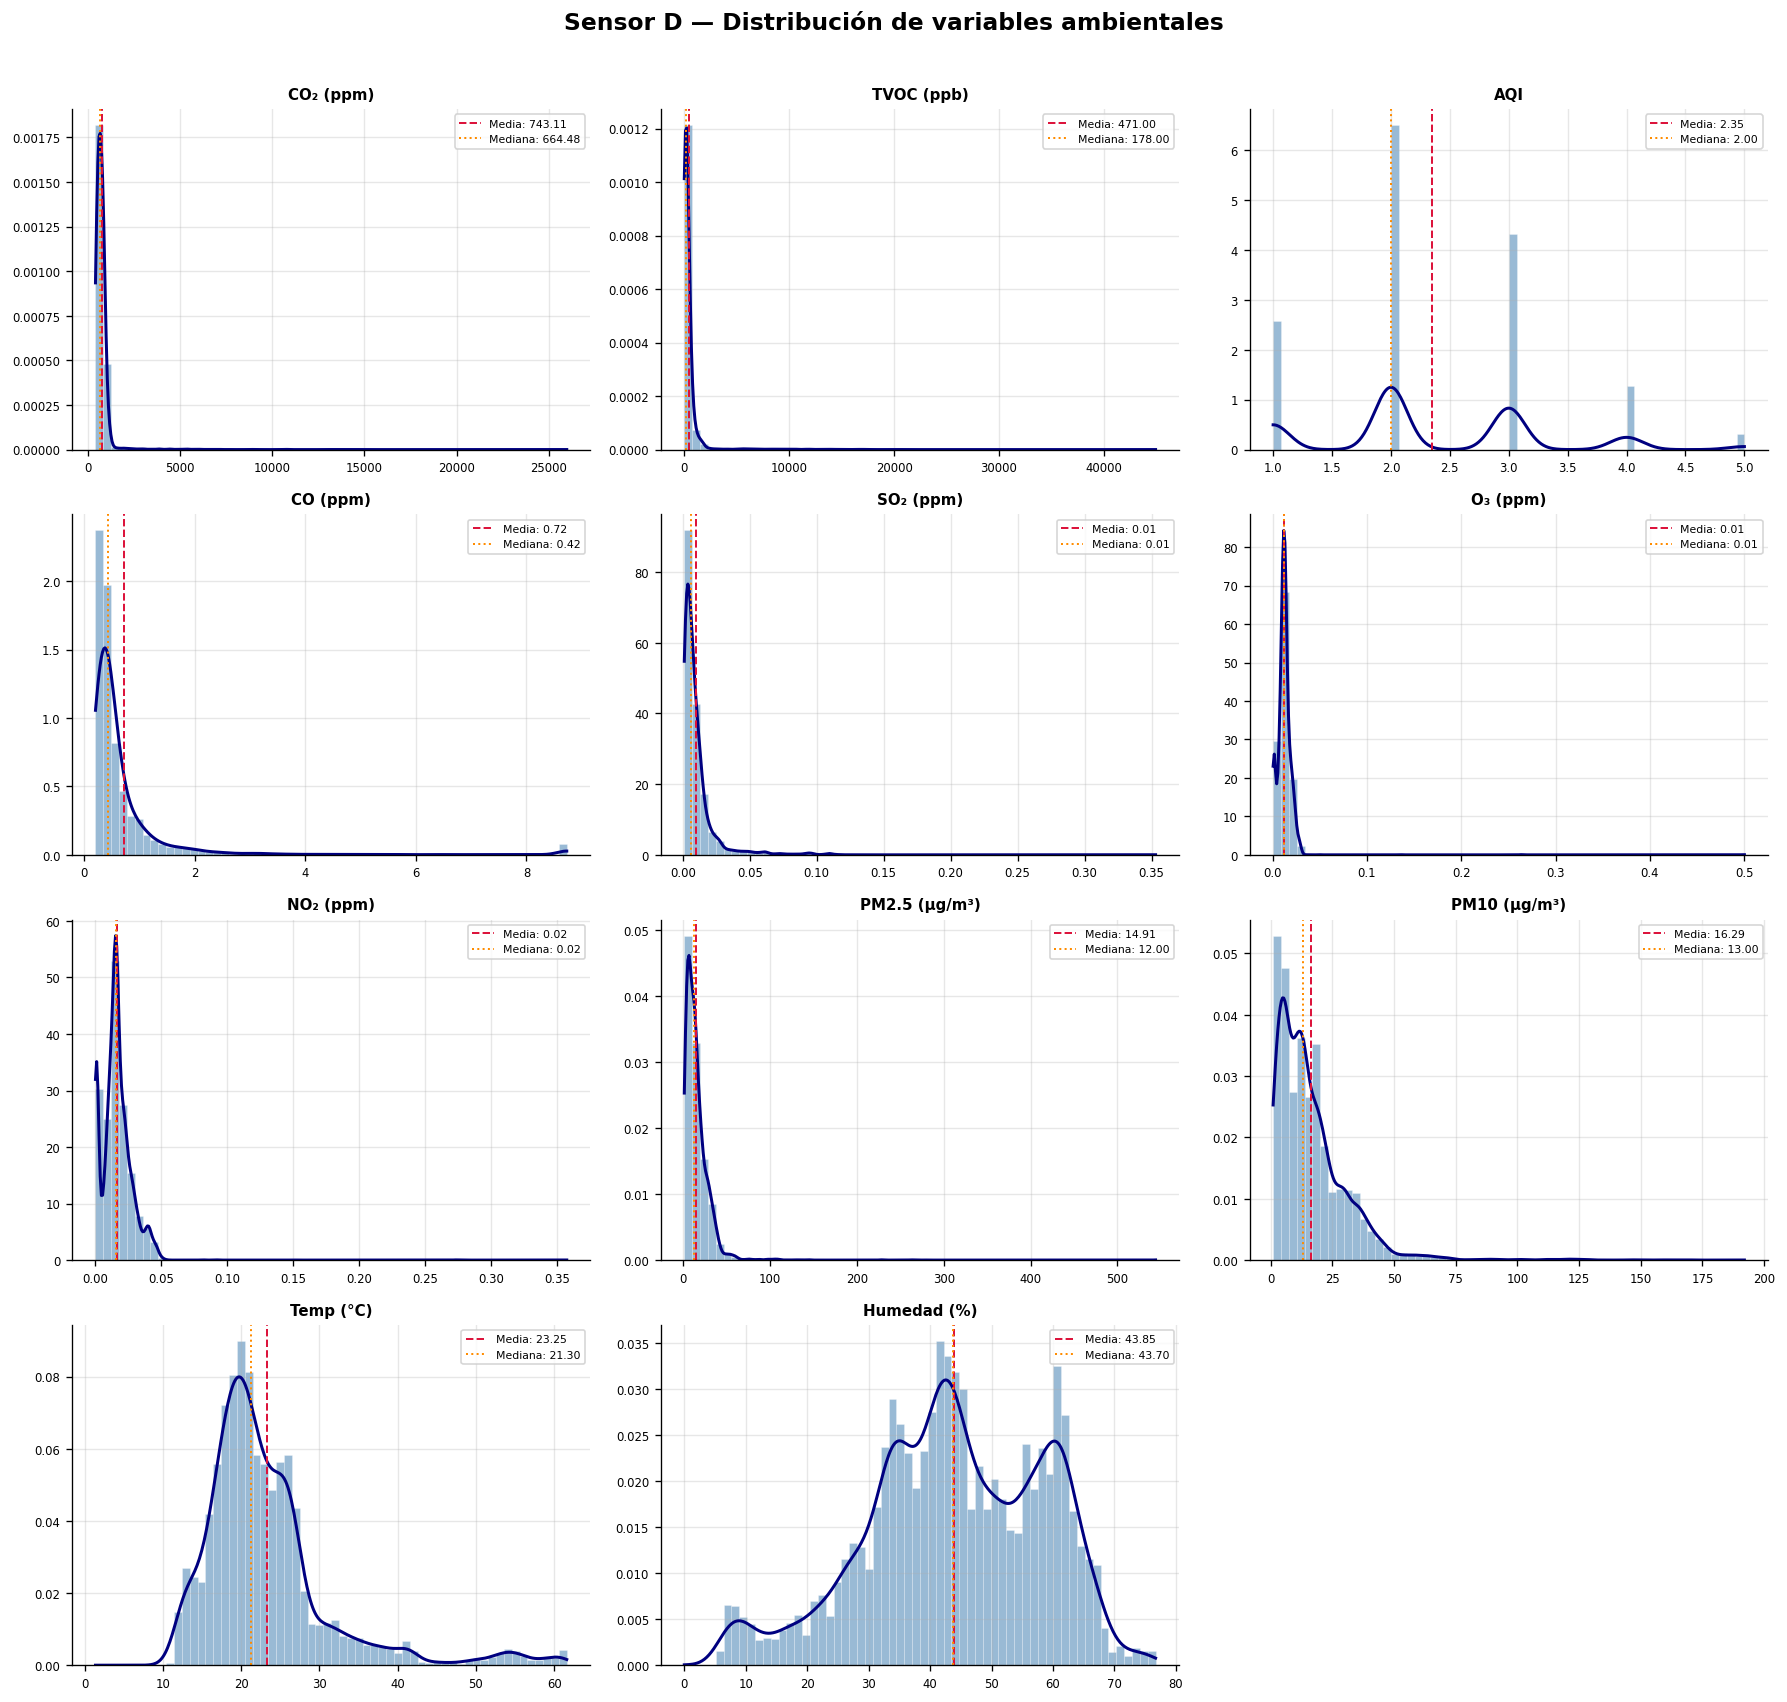

In [11]:
labels = ['CO₂ (ppm)','TVOC (ppb)','AQI','CO (ppm)','SO₂ (ppm)',
          'O₃ (ppm)','NO₂ (ppm)','PM2.5 (µg/m³)','PM10 (µg/m³)','Temp (°C)','Humedad (%)']

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
fig.suptitle('Sensor D — Distribución de variables ambientales', fontsize=14, fontweight='bold', y=1.01)

for ax, col, lbl in zip(axes.flat, vars_ambientales, labels):
    data = sensor_d[col].dropna().values
    ax.hist(data, bins=60, color='steelblue', alpha=0.55, density=True,
            edgecolor='white', linewidth=0.3)
    try:
        kde = gaussian_kde(data)
        xs = np.linspace(data.min(), data.max(), 400)
        ax.plot(xs, kde(xs), color='navy', linewidth=1.8)
    except Exception:
        pass
    ax.axvline(data.mean(), color='crimson', linestyle='--', linewidth=1.2,
               label=f'Media: {data.mean():.2f}')
    ax.axvline(np.median(data), color='darkorange', linestyle=':', linewidth=1.2,
               label=f'Mediana: {np.median(data):.2f}')
    ax.set_title(lbl, fontsize=9, fontweight='bold')
    ax.legend(fontsize=6.5)
    ax.tick_params(labelsize=7)

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig('Data/02_distribuciones_sensorD.png', dpi=130, bbox_inches='tight')
plt.show()

**Observaciones:**
- La mayoría de los contaminantes (`CO_ppm`, `TVOC_ppb`, `CO2_ppm`) presentan distribuciones asimétricas hacia la derecha, con la masa de datos concentrada en valores bajos y colas largas de eventos extremos.
- `AQI` tiene una distribución discreta (valores enteros 1–5), lo que confirma que es un índice categórico ordinal.
- `temp_C` y `hum_pct` muestran distribuciones más simétricas, típicas de variables meteorológicas.
- La diferencia entre media y mediana en variables como `TVOC_ppb` y `CO2_ppm` confirma el efecto de los outliers sobre la media.

---
## 7. Series temporales

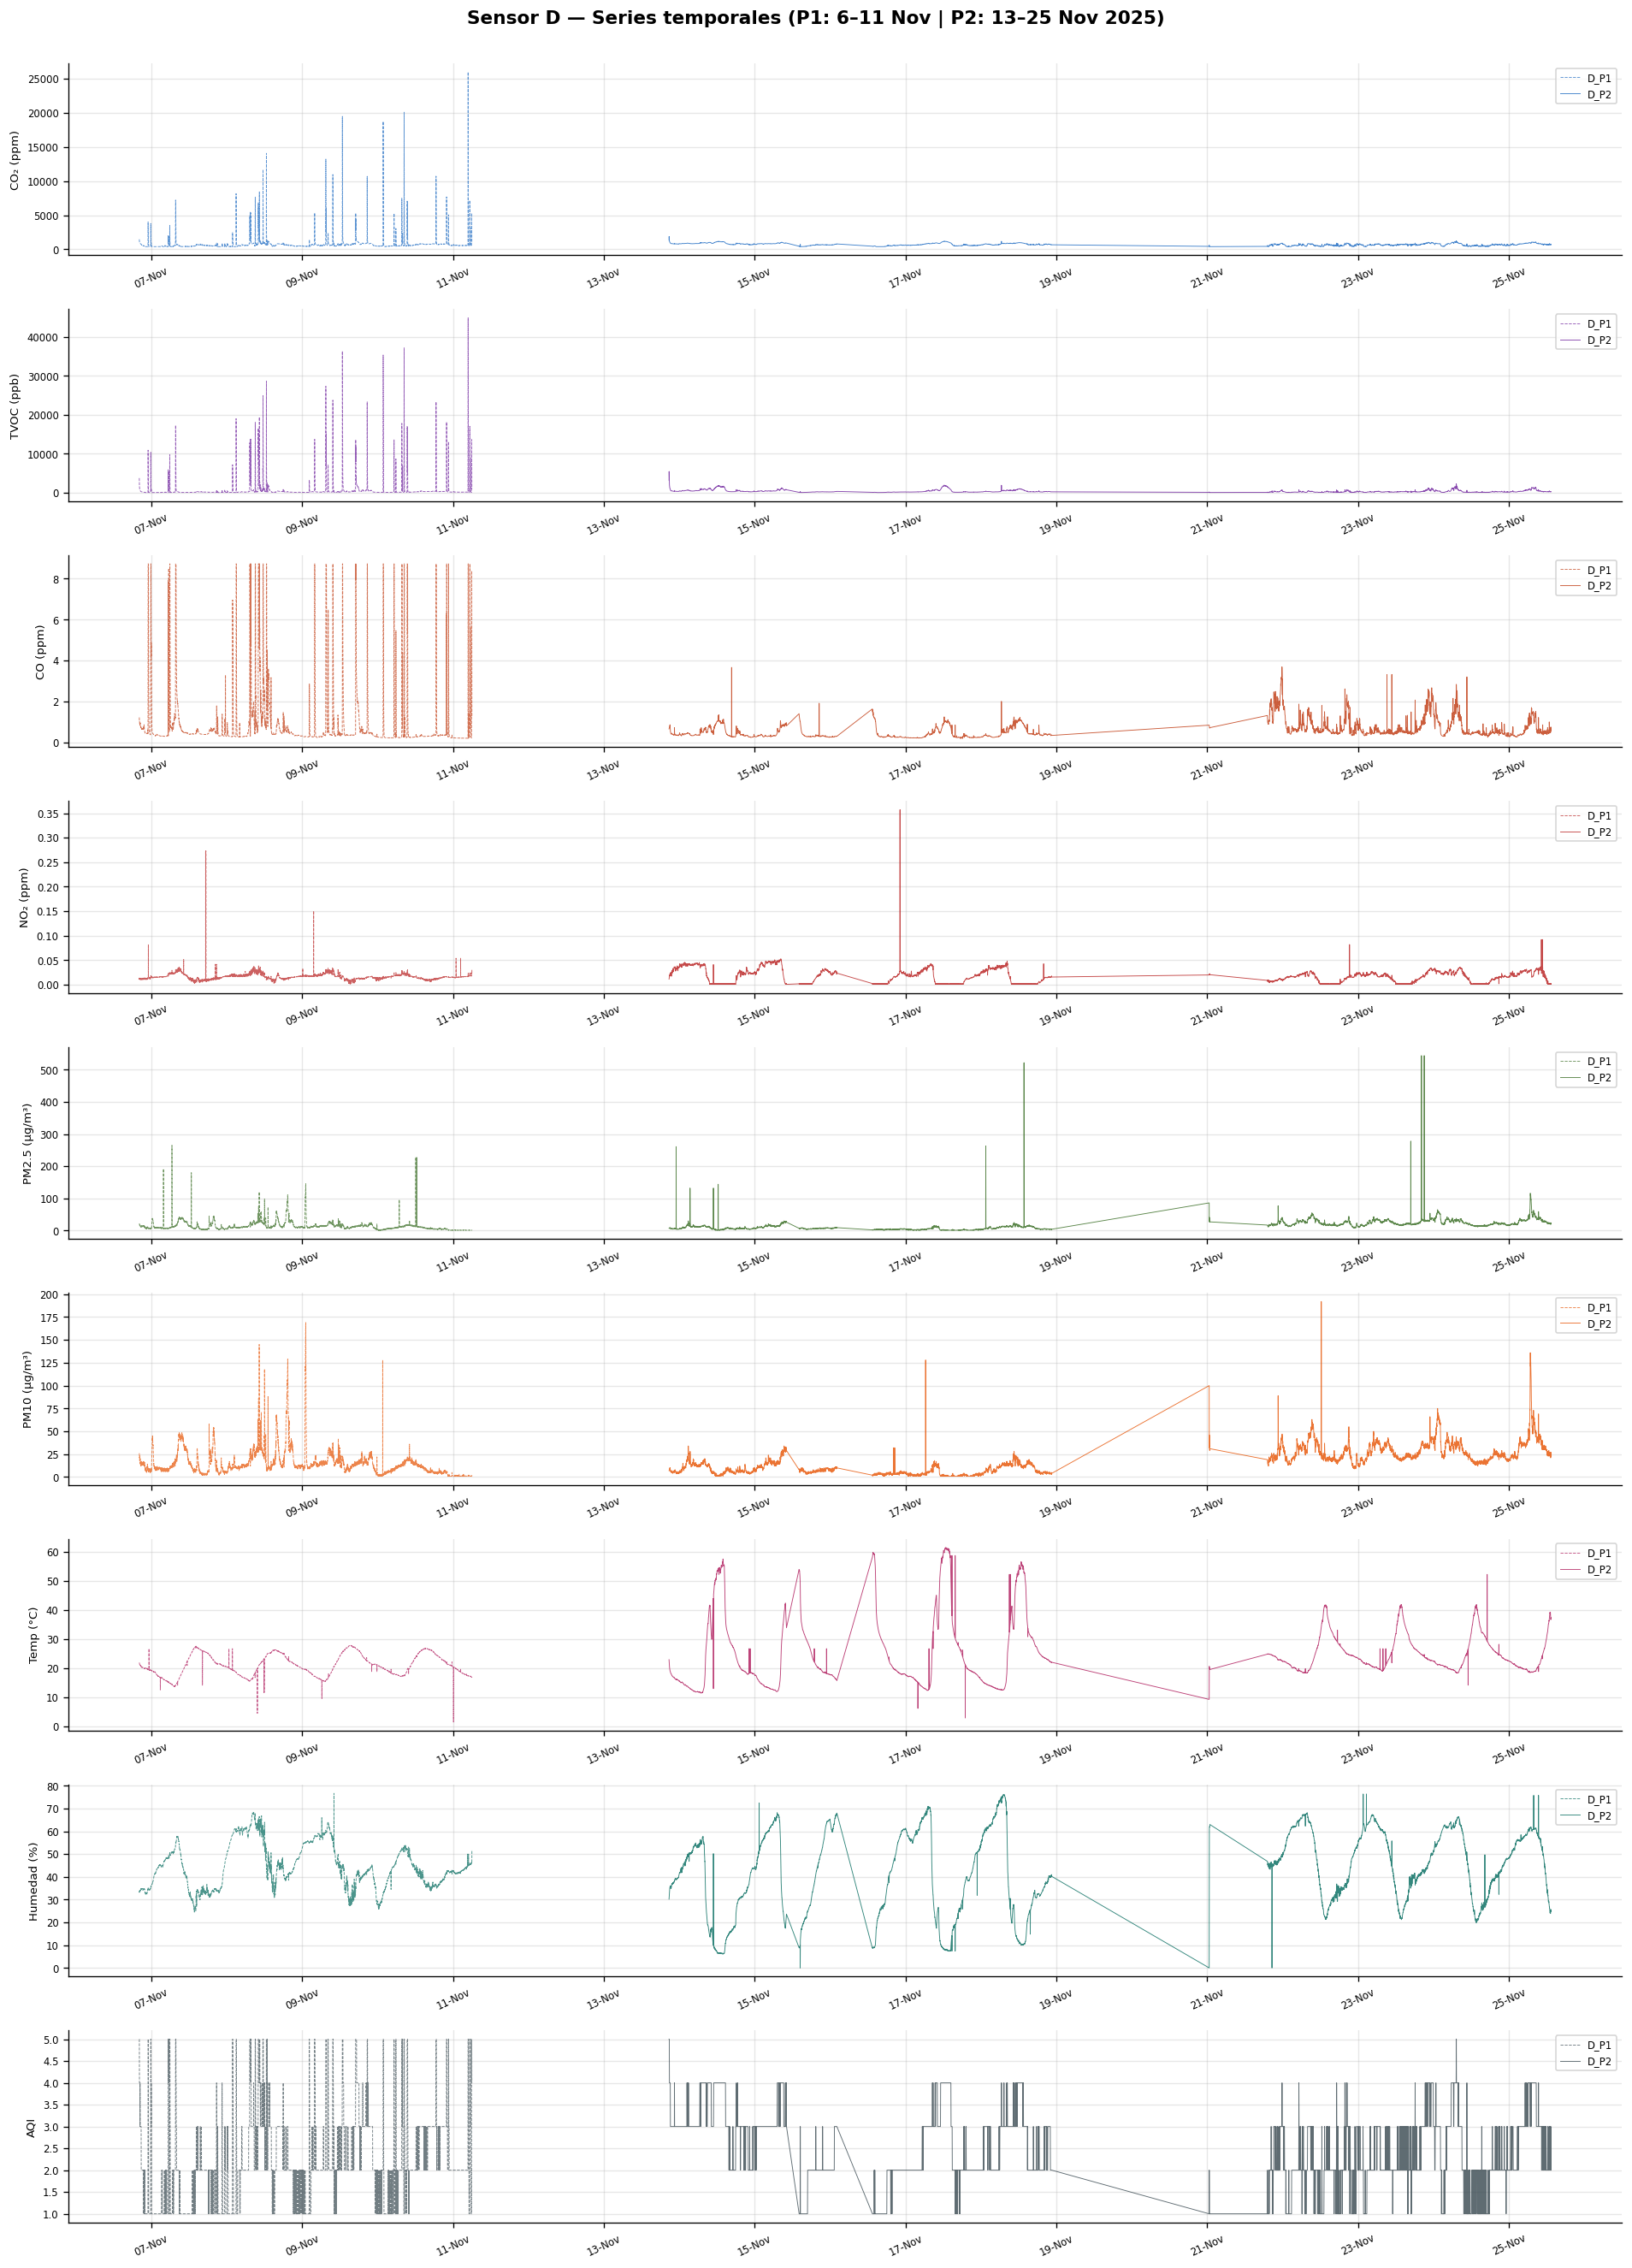

In [12]:
vars_plot = ['CO2_ppm','TVOC_ppb','CO_ppm','NO2_ppm','PM2_5_ugm3','PM10_ugm3','temp_C','hum_pct','AQI']
labels_plot = ['CO₂ (ppm)','TVOC (ppb)','CO (ppm)','NO₂ (ppm)',
               'PM2.5 (µg/m³)','PM10 (µg/m³)','Temp (°C)','Humedad (%)','AQI']
colores = ['#1565C0','#6A1B9A','#BF360C','#B71C1C','#33691E','#E65100','#AD1457','#00695C','#37474F']

fig, axes = plt.subplots(len(vars_plot), 1, figsize=(16, 22), sharex=False)
fig.suptitle('Sensor D — Series temporales (P1: 6–11 Nov | P2: 13–25 Nov 2025)',
             fontsize=13, fontweight='bold', y=1.002)

for ax, col, lbl, clr in zip(axes, vars_plot, labels_plot, colores):
    for sp, ls, alpha in [('D_P1', '--', 0.7), ('D_P2', '-', 0.8)]:
        sub = sensor_d[sensor_d['sensor_periodo'] == sp]
        ax.plot(sub['datetime'], sub[col], linewidth=0.55, color=clr,
                alpha=alpha, linestyle=ls, label=sp)
    ax.set_ylabel(lbl, fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.tick_params(axis='x', rotation=25, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('Data/01_series_temporales_sensorD.png', dpi=130, bbox_inches='tight')
plt.show()

**Observaciones:**
- Se observan picos marcados en `CO2_ppm` y `TVOC_ppb` durante ambos periodos, probablemente asociados a eventos de cocción, tráfico o actividad humana intensa.
- Las partículas (`PM2_5`, `PM10`) muestran variabilidad diaria con picos recurrentes, lo que podría estar relacionado con horas pico de tráfico.
- La temperatura presenta ciclos diurnos claros (subida en el día, caída en la noche), lo que confirma que el sensor está respondiendo a condiciones reales.
- El `AQI` se mantiene en niveles bajos la mayor parte del tiempo, con esporádicos saltos a nivel 4–5.

### Brecha de datos: 19–20 de noviembre

Al observar las series temporales se aprecia un **salto visible alrededor del 20 de noviembre**. Esto no es un error de la gráfica: es una **brecha real en los datos** del Sensor D durante el periodo P2.

| Día | Registros | Observación |
|---|---|---|
| 2025-11-18 | 862 | Normal, último registro: 22:30 h |
| **2025-11-19** | **0** | **Sin datos** |
| **2025-11-20** | **0** | **Sin datos** |
| 2025-11-21 | 196 | Reinicio del sensor a las 00:35 h |
| 2025-11-22 | 919 | Normal |

**Duración de la brecha:** ~50 horas (18-Nov 22:30 → 21-Nov 00:35).

**Causa probable:** La batería bajó de **78 % → 61.4 %** durante el silencio, lo que descarta agotamiento de batería. Lo más probable es un **corte de energía, fallo de conectividad o apagado manual** del dispositivo.

> **Implicación para el modelado:** matplotlib conecta el último punto del 18-Nov con el primero del 21-Nov, generando una línea ficticia. Si se usan *lags* o ventanas temporales como features, esta brecha debe marcarse para evitar que el modelo aprenda una transición que nunca ocurrió.

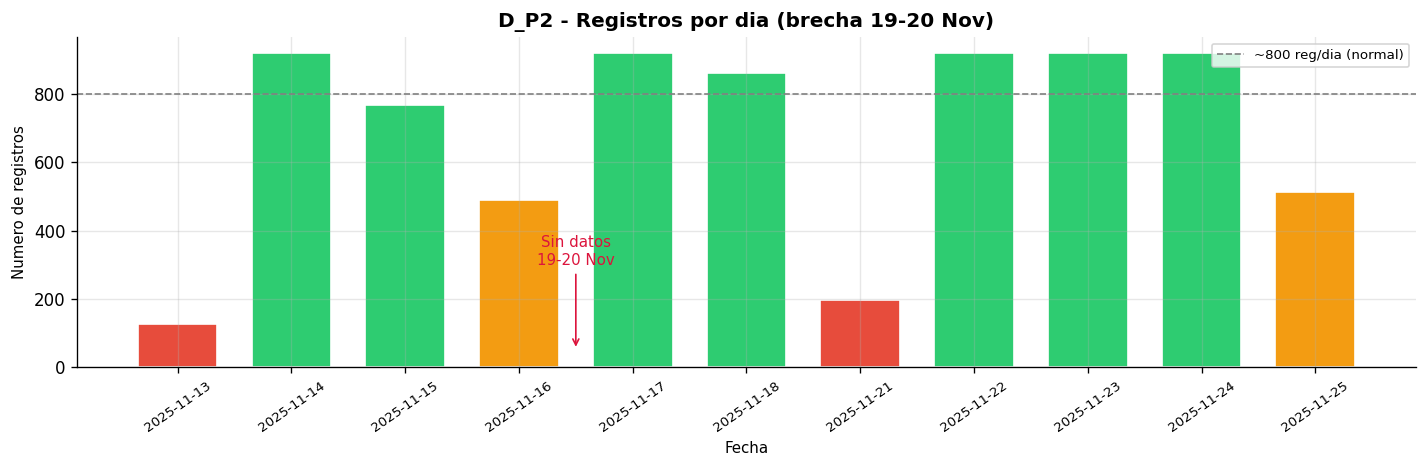

Duracion de la brecha: 2 days 02:05:49
Registros marcados como brecha: 0 (debe ser 0 — no hay datos en ese intervalo)


In [13]:
# Diagnóstico de la brecha en D_P2
registros_dia = (
    sensor_d[sensor_d['sensor_periodo'] == 'D_P2']
    .groupby(sensor_d['datetime'].dt.date)
    .size()
    .reset_index()
)
registros_dia.columns = ['fecha', 'registros']

fig, ax = plt.subplots(figsize=(12, 4))
colores_barra = ['#e74c3c' if r < 200 else '#f39c12' if r < 700 else '#2ecc71'
                 for r in registros_dia['registros']]
ax.bar(registros_dia['fecha'].astype(str), registros_dia['registros'],
       color=colores_barra, edgecolor='white', width=0.7)
ax.axhline(800, color='gray', linestyle='--', linewidth=1, label='~800 reg/dia (normal)')
ax.set_title('D_P2 - Registros por dia (brecha 19-20 Nov)', fontsize=12, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=9)
ax.set_ylabel('Numero de registros', fontsize=9)
ax.tick_params(axis='x', rotation=35, labelsize=8)
ax.legend(fontsize=8)

# Anotar la brecha
ax.annotate('Sin datos' + chr(10) + '19-20 Nov', xy=(3.5, 50), xytext=(3.5, 300),
            arrowprops=dict(arrowstyle='->', color='crimson'),
            color='crimson', fontsize=9, ha='center')

plt.tight_layout()
plt.savefig('Data/07_brecha_datos_sensorD.png', dpi=130, bbox_inches='tight')
plt.show()

# Marcar la brecha en el dataframe para uso posterior
BRECHA_INICIO = pd.Timestamp('2025-11-18 22:30:00')
BRECHA_FIN    = pd.Timestamp('2025-11-21 00:35:49')
sensor_d['en_brecha'] = (
    (sensor_d['datetime'] > BRECHA_INICIO) & (sensor_d['datetime'] < BRECHA_FIN)
)
duracion = BRECHA_FIN - BRECHA_INICIO
marcados  = sensor_d['en_brecha'].sum()
print('Duracion de la brecha:', duracion)
print('Registros marcados como brecha:', marcados, '(debe ser 0 — no hay datos en ese intervalo)')


---
## 8. Matriz de correlaciones

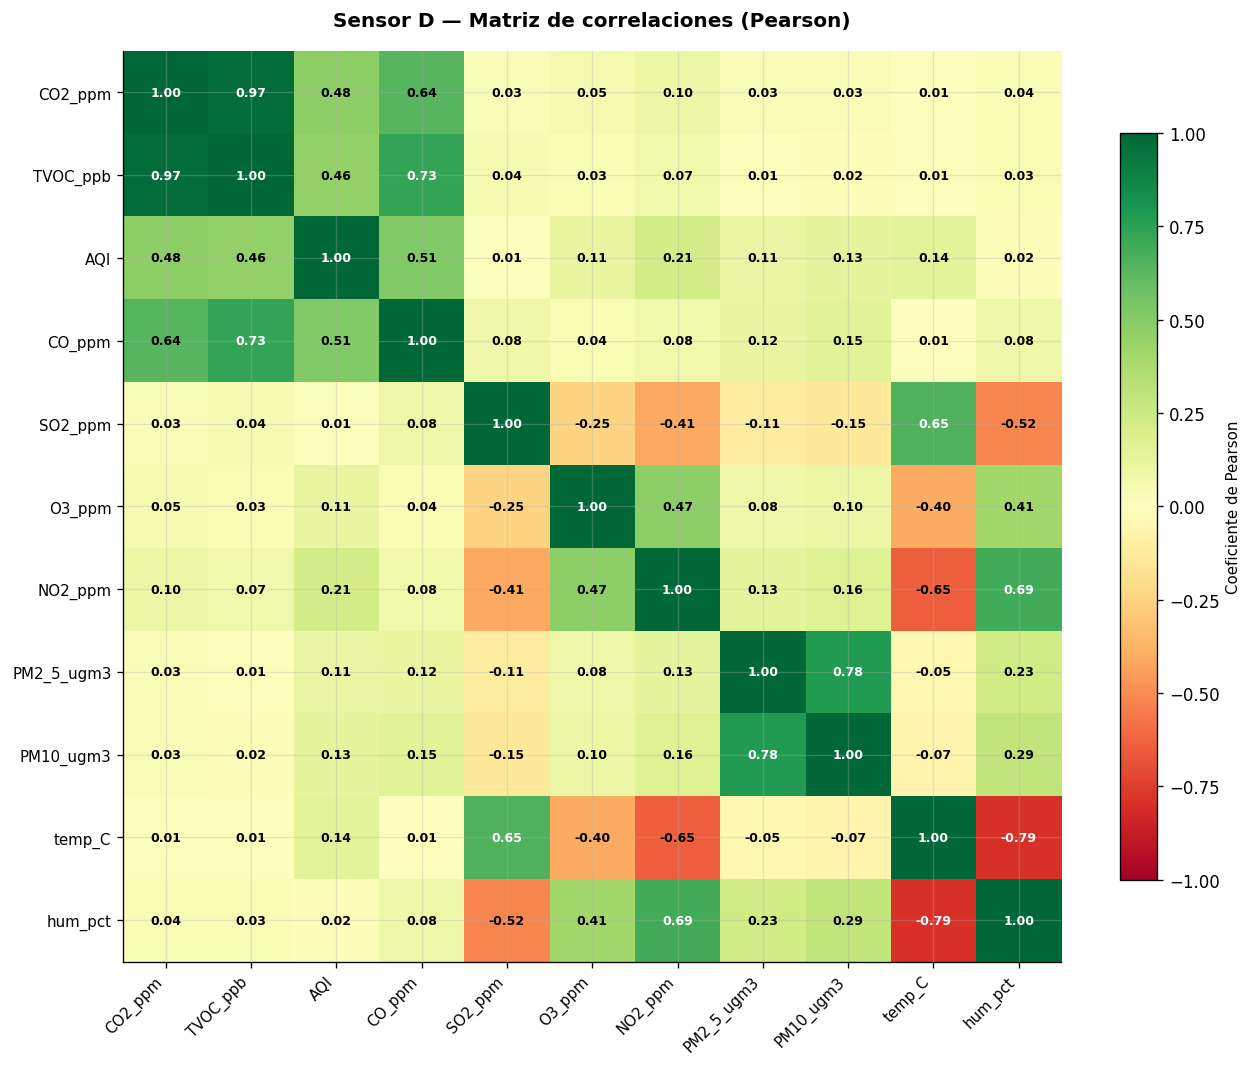

In [14]:
corr = sensor_d[vars_ambientales].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
cbar = plt.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label('Coeficiente de Pearson', fontsize=9)

ax.set_xticks(range(len(vars_ambientales)))
ax.set_yticks(range(len(vars_ambientales)))
ax.set_xticklabels(vars_ambientales, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(vars_ambientales, fontsize=9)
ax.set_title('Sensor D — Matriz de correlaciones (Pearson)', fontsize=12, fontweight='bold', pad=15)

for i in range(len(vars_ambientales)):
    for j in range(len(vars_ambientales)):
        val = corr.values[i, j]
        color = 'white' if abs(val) >= 0.65 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7.5,
                color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('Data/03_correlaciones_sensorD.png', dpi=130, bbox_inches='tight')
plt.show()

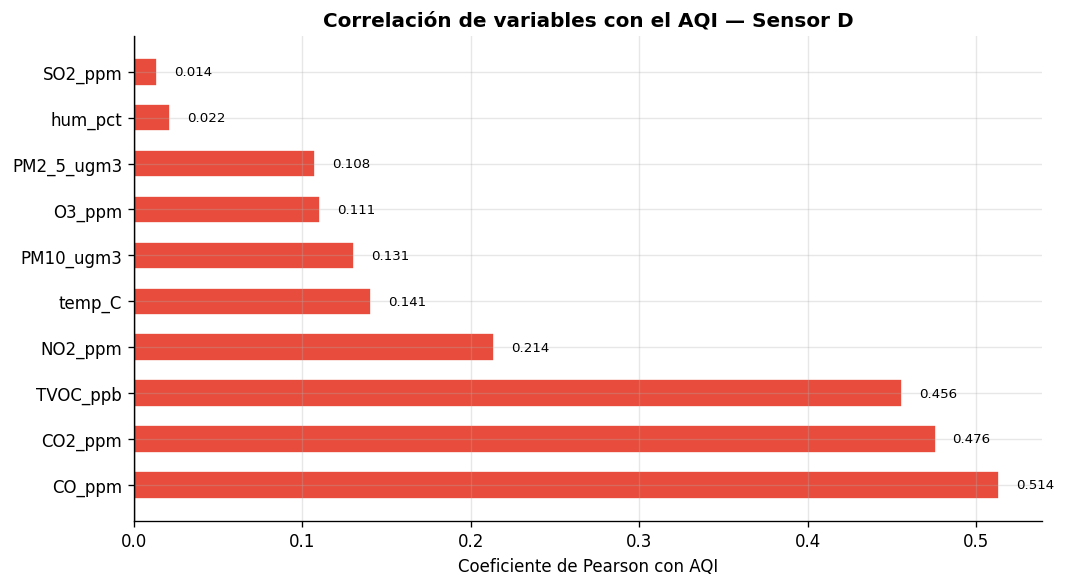

In [15]:
# Correlación ordenada con AQI
corr_aqi = corr['AQI'].drop('AQI').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in corr_aqi.values]
bars = ax.barh(corr_aqi.index, corr_aqi.values, color=colors_bar, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente de Pearson con AQI', fontsize=10)
ax.set_title('Correlación de variables con el AQI — Sensor D', fontsize=12, fontweight='bold')
for bar, val in zip(bars, corr_aqi.values):
    ax.text(val + 0.01 * np.sign(val), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('Data/04_correlacion_aqi_sensorD.png', dpi=130, bbox_inches='tight')
plt.show()

**Interpretación de correlaciones:**

| Variable | r con AQI | Interpretación |
|---|---|---|
| `CO_ppm` | 0.51 | Correlación moderada-alta; el CO es un predictor importante del AQI |
| `CO2_ppm` | 0.48 | Correlación moderada; refleja eventos de combustión |
| `TVOC_ppb` | 0.46 | Correlación moderada; contaminantes orgánicos relacionados con calidad del aire |
| `NO2_ppm` | 0.21 | Correlación baja-moderada |
| `PM2_5_ugm3` / `PM10_ugm3` | ~0.11 | Baja correlación lineal; podría haber relación no lineal |
| `hum_pct` / `SO2_ppm` | ~0.01–0.02 | Sin correlación lineal significativa |

> **CO, CO₂ y TVOC** son los predictores lineales más fuertes del AQI. Las partículas y otros gases podrían ser relevantes mediante relaciones no lineales.

---
## 9. Análisis por hora del día

Explorar si existen patrones diurnos en los contaminantes (horas pico, tráfico, actividad humana).

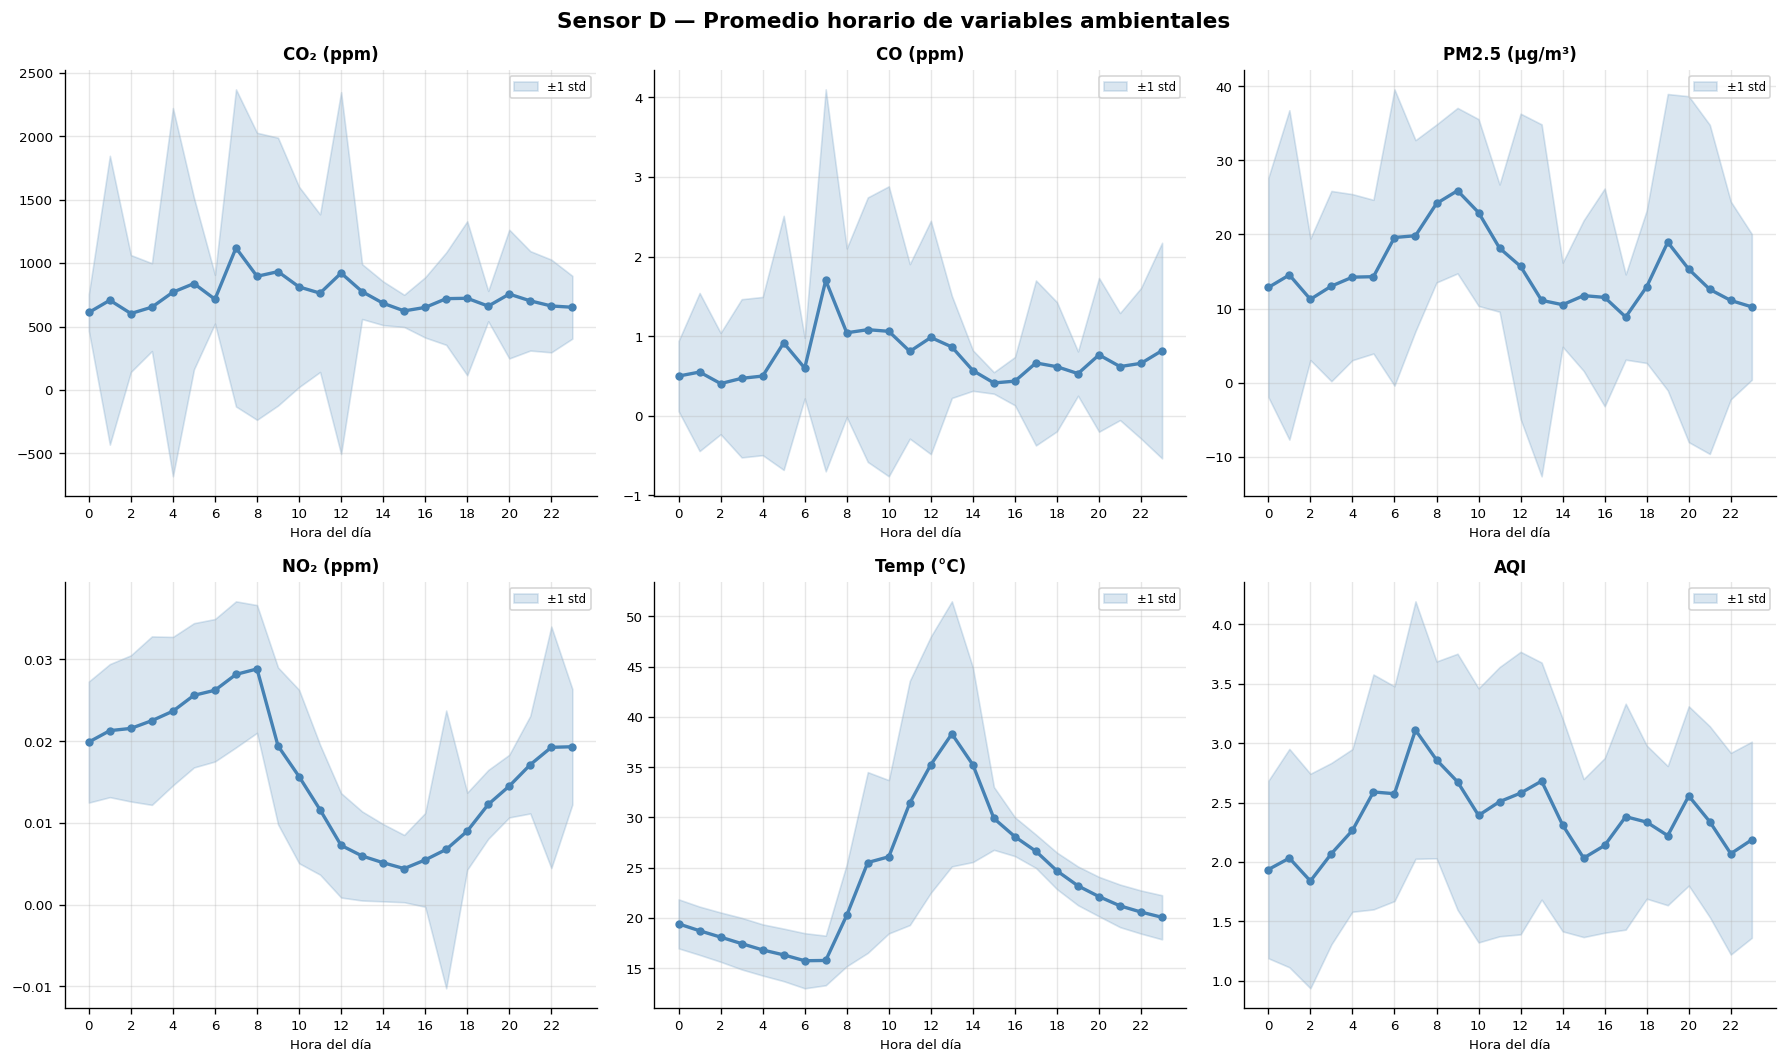

In [16]:
sensor_d['hora'] = sensor_d['datetime'].dt.hour

vars_hora = ['CO2_ppm','CO_ppm','PM2_5_ugm3','NO2_ppm','temp_C','AQI']
labels_hora = ['CO₂ (ppm)','CO (ppm)','PM2.5 (µg/m³)','NO₂ (ppm)','Temp (°C)','AQI']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Sensor D — Promedio horario de variables ambientales', fontsize=13, fontweight='bold')

for ax, col, lbl in zip(axes.flat, vars_hora, labels_hora):
    media_hora = sensor_d.groupby('hora')[col].mean()
    std_hora   = sensor_d.groupby('hora')[col].std()

    ax.plot(media_hora.index, media_hora.values, color='steelblue', linewidth=2, marker='o', markersize=4)
    ax.fill_between(media_hora.index,
                    media_hora.values - std_hora.values,
                    media_hora.values + std_hora.values,
                    alpha=0.2, color='steelblue', label='±1 std')
    ax.set_title(lbl, fontsize=10, fontweight='bold')
    ax.set_xlabel('Hora del día', fontsize=8)
    ax.set_xticks(range(0, 24, 2))
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('Data/05_patron_horario_sensorD.png', dpi=130, bbox_inches='tight')
plt.show()

**Observaciones del patrón horario:**
- `CO2_ppm` y `CO_ppm` presentan picos en las primeras horas de la mañana (~6–8 am) y al mediodía, consistentes con horas pico de tráfico y actividad humana.
- `temp_C` muestra el ciclo diurno esperado: mínima en madrugada (~4–6 am) y máxima a media tarde (~14–16 hrs).
- `PM2_5_ugm3` tiende a elevarse en horas de mayor actividad (mañana y tarde), con una leve caída nocturna.
- `AQI` sigue un patrón similar a los contaminantes gaseosos, con niveles más altos durante el día.

---
## 10. Comparación entre periodos (D_P1 vs D_P2)

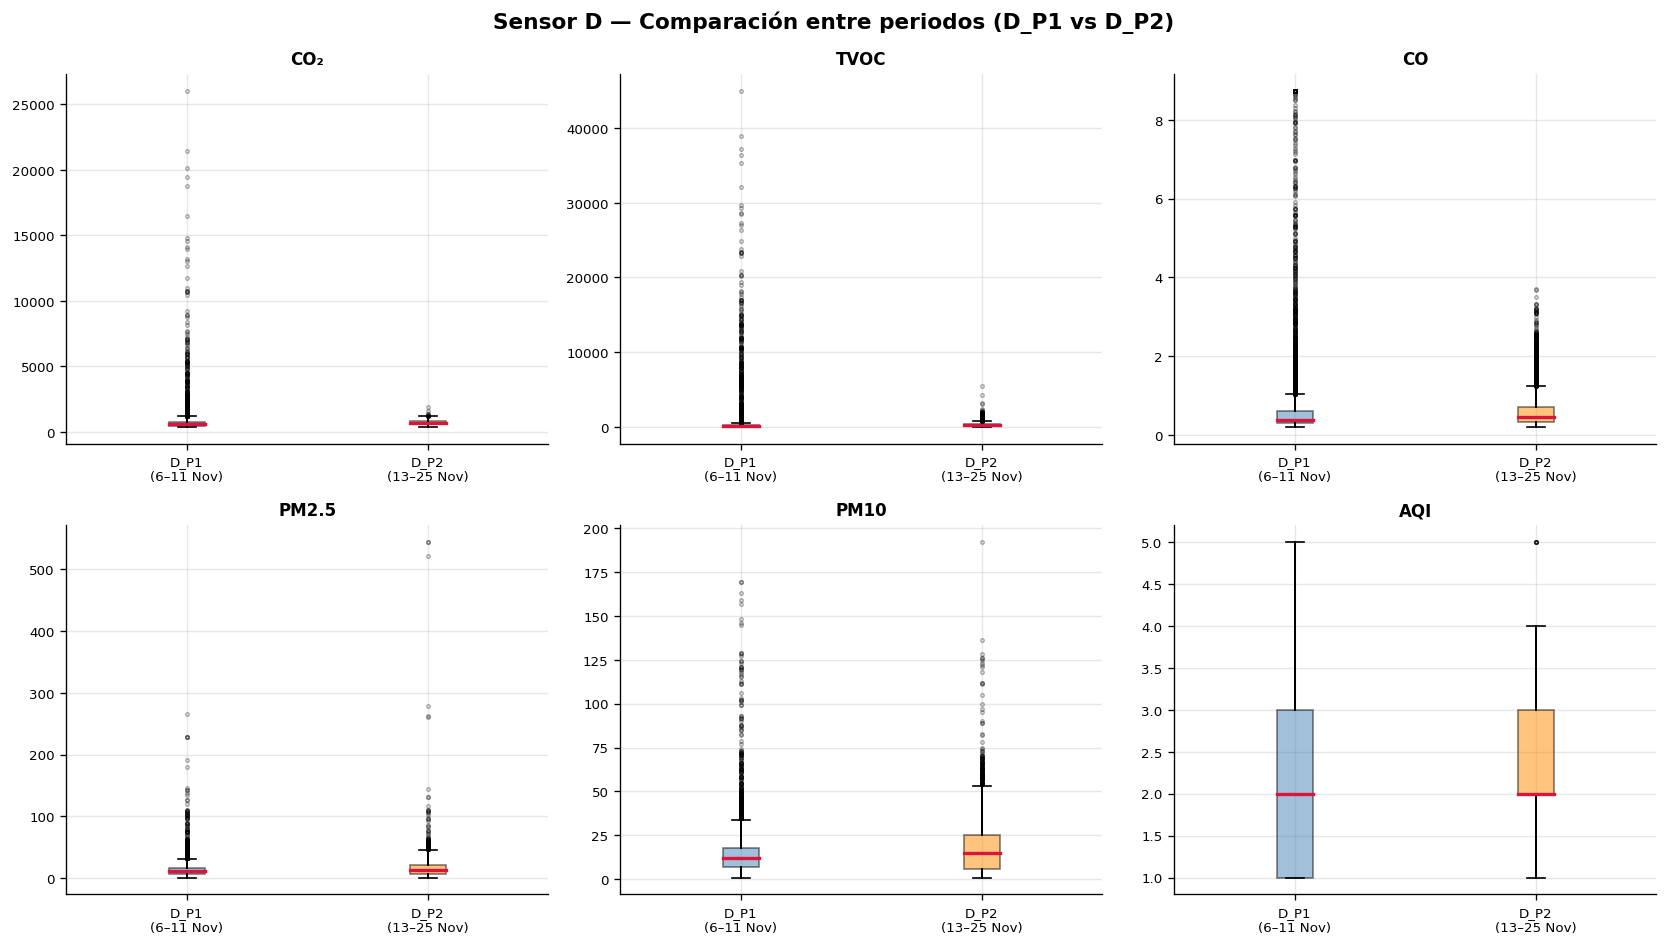

In [17]:
vars_box = ['CO2_ppm','TVOC_ppb','CO_ppm','PM2_5_ugm3','PM10_ugm3','AQI']
labels_box = ['CO₂','TVOC','CO','PM2.5','PM10','AQI']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Sensor D — Comparación entre periodos (D_P1 vs D_P2)', fontsize=13, fontweight='bold')

p1 = sensor_d[sensor_d['sensor_periodo'] == 'D_P1']
p2 = sensor_d[sensor_d['sensor_periodo'] == 'D_P2']

for ax, col, lbl in zip(axes.flat, vars_box, labels_box):
    data = [p1[col].dropna().values, p2[col].dropna().values]
    bp = ax.boxplot(data, labels=['D_P1\n(6–11 Nov)', 'D_P2\n(13–25 Nov)'],
                    patch_artist=True, notch=False,
                    boxprops=dict(facecolor='steelblue', alpha=0.5),
                    medianprops=dict(color='crimson', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3, color='gray'))
    bp['boxes'][1].set_facecolor('#FF8C00')
    ax.set_title(lbl, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('Data/06_boxplot_periodos_sensorD.png', dpi=130, bbox_inches='tight')
plt.show()

In [18]:
# Resumen estadístico por periodo
print('=== Media por periodo ===')
display(
    sensor_d.groupby('sensor_periodo')[vars_ambientales].mean().round(3)
)

=== Media por periodo ===


,CO2_ppm,TVOC_ppb,AQI,CO_ppm,SO2_ppm,O3_ppm,NO2_ppm,PM2_5_ugm3,PM10_ugm3,temp_C,hum_pct
sensor_periodo,,,,,,,,,,,
D_P1,771.227,638.589,2.192,0.872,0.006,0.012,0.016,13.504,14.833,21.006,44.592
D_P2,719.993,333.195,2.478,0.600,0.014,0.013,0.017,16.058,17.489,25.099,43.236


---
## 11. Resumen y conclusiones del EDA

### Variables más relevantes para modelar AQI

Con base en el análisis de correlaciones y distribuciones, las variables con mayor potencial predictivo son:

1. **`CO_ppm`** — Mayor correlación con AQI (r ≈ 0.51); gas producto de combustión incompleta.
2. **`CO2_ppm`** — Correlación moderada (r ≈ 0.48); refleja la carga de actividad humana y de combustión.
3. **`TVOC_ppb`** — Correlación moderada (r ≈ 0.46); agrupa múltiples compuestos orgánicos.
4. **`NO2_ppm`** — Correlación baja-moderada (r ≈ 0.21); relevante como precursor de ozono.
5. **`PM2_5_ugm3` / `PM10_ugm3`** — Baja correlación lineal, pero físicamente importante para la salud.
6. **`temp_C`** — Influye en la dispersión de contaminantes y formación de ozono.

### Decisiones de preprocesamiento sugeridas

| Aspecto | Recomendación |
|---|---|
| Outliers | Aplicar winsorización al percentil 99 en `CO2_ppm`, `TVOC_ppb` y `CO_ppm` |
| Escala | Normalizar (Min-Max o Z-score) antes de entrenar modelos sensibles a escala |
| Variable objetivo | `AQI` (clasificación ordinal 1–5) o tratar como regresión |
| Variables a excluir | `Bat_pct` (operacional), `SO2_ppm` y `hum_pct` (baja correlación) |
| Ingeniería de características | Considerar `hora`, `día de semana` como features temporales |

> El Sensor D en el periodo combinado P1+P2 proporciona **13,758 observaciones sin valores nulos**, una base sólida para entrenar y validar modelos de predicción de calidad del aire.